**Import Libraries**

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [36]:
df = pd.read_csv("Master_DS.csv")

df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Mortgage_Approvals,Net_Consumer_Credit,Net_Credit_Card_Lending
0,1995-01,1995,January,6.63,2.4,8.9,19.6,0.5,78866,399,162
1,1995-02,1995,February,6.63,2.4,8.9,19.6,0.5,80654,452,186
2,1995-03,1995,March,6.63,2.6,8.8,19.6,0.5,74872,535,158
3,1995-04,1995,April,6.63,2.3,8.8,19.8,0.2,75112,303,153
4,1995-05,1995,May,6.63,2.5,8.7,19.8,0.2,70629,276,182


In [37]:
print(df["Bank_Rate"].describe())
print(df["CPI"].describe())
print(df["GDP_Growth"].describe())
print(df["Unemployment_Rate"].describe())

count    372.000000
mean       3.089597
std        2.459424
min        0.100000
25%        0.500000
50%        4.000000
75%        5.250000
max        7.500000
Name: Bank_Rate, dtype: float64
count    372.000000
mean       2.463978
std        1.916574
min       -0.100000
25%        1.400000
50%        2.100000
75%        2.900000
max       11.100000
Name: CPI, dtype: float64
count    372.000000
mean       0.496774
std        2.515835
min      -19.900000
25%        0.200000
50%        0.600000
75%        0.800000
max       17.000000
Name: GDP_Growth, dtype: float64
count    372.000000
mean       5.702957
std        1.444524
min        3.600000
25%        4.700000
50%        5.200000
75%        6.700000
max        8.900000
Name: Unemployment_Rate, dtype: float64


In [38]:
conditions = pd.DataFrame({
    "High_Bank_Rate": df["Bank_Rate"] > 5.25,
    "High_CPI": df["CPI"] > 5.0,
    "Negative_GDP": df["GDP_Growth"] < 0,
    "High_Unemployment": df["Unemployment_Rate"] > 6.7
})

df["Economy_Status"] = (
    conditions.sum(axis=1) >= 2
).astype(int)

In [39]:
df["Economy_Status"].value_counts()

,count
Economy_Status,
0,324
1,48


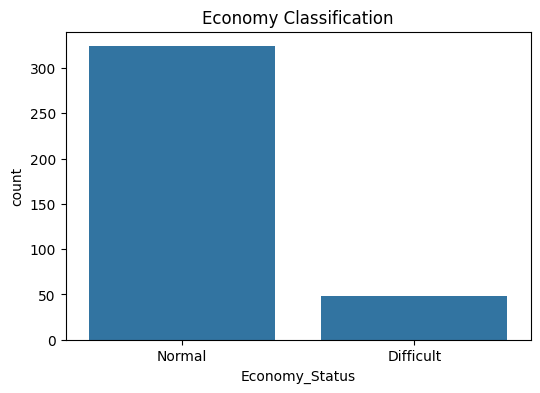

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x="Economy_Status", data=df)

plt.xticks([0,1],["Normal","Difficult"])

plt.title("Economy Classification")

plt.show()

In [41]:
X = df[
    [
        "Bank_Rate",
        "CPI",
        "Unemployment_Rate",
        "House_Price_Index",
        "GDP_Growth"
    ]
]

y = df["Economy_Status"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [43]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Model Successfully Trained")

Model Successfully Trained


In [44]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [45]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :",accuracy)

Accuracy : 0.9333333333333333


In [46]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision :",precision)

Precision : 0.8571428571428571


In [47]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall :",recall)

Recall : 0.6


In [49]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC :",auc)

ROC AUC : 0.98


In [50]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[64,  1],
       [ 4,  6]])

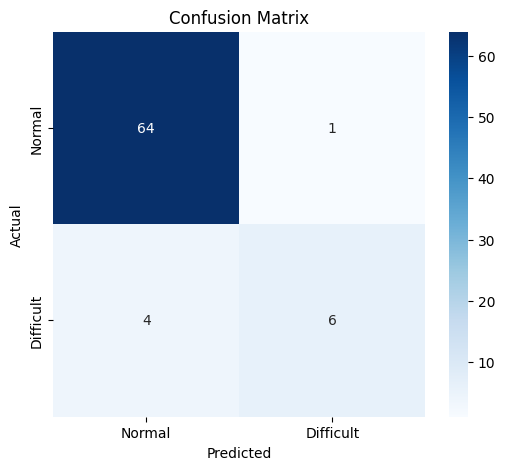

In [51]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Normal","Difficult"],

    yticklabels=["Normal","Difficult"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [52]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        65
           1       0.86      0.60      0.71        10

    accuracy                           0.93        75
   macro avg       0.90      0.79      0.83        75
weighted avg       0.93      0.93      0.93        75

